# Part 1: Neural Network Fundamentals and Training Behavior Analysis

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report, f1_score, recall_score, precision_score)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)
print('Tensorflow version:',tf.__version__)

Tensorflow version: 2.21.0


# Task 1: Dataset Understanding

In [11]:
df = pd.read_csv(r'C:\Users\ACER\Downloads\customer_churn_nn.csv')

print('_' * 60)
print(f'Rows: {df.shape[0]} |  Columns: {df.shape[1]}')
print('_' * 60)
df.head()

____________________________________________________________
Rows: 2000 |  Columns: 17
____________________________________________________________


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [12]:
print('Column data types')
print('_' * 60)
print(df.dtypes)
print()
print('Categorical columns:', ['region', 'plan_type', 'contract_type', 'payment_method'])
print('Numerical columns (11):', df.select_dtypes(include='number').columns.drop('churn').tolist())
print('Target column: churn (0 = retained, 1 = churned)')

Column data types
____________________________________________________________
customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Categorical columns: ['region', 'plan_type', 'contract_type', 'payment_method']
Numerical columns (11): ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days',

In [13]:
print('Missing Values per Column')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing Values per Column
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

Total missing values: 0


In [14]:
print('Statistical Summary (Numerical Features)')
df.describe().T.round(2)

Statistical Summary (Numerical Features)


,count,mean,std,min,25%,50%,75%,max
tenure_months,2000.0,25.36,14.13,1.00,15.00,23.00,33.00,72.00
monthly_charges_inr,2000.0,766.49,393.42,255.45,427.78,688.36,1007.37,2156.52
avg_login_days_per_month,2000.0,18.10,5.40,0.00,15.00,18.00,22.00,30.00
support_tickets_last_90_days,2000.0,1.95,1.46,0.00,1.00,2.00,3.00,8.00
payment_delay_days,2000.0,3.56,3.89,0.00,1.00,2.00,5.00,31.00
data_usage_gb,2000.0,90.01,53.22,0.50,51.78,80.24,119.10,265.51
satisfaction_score,2000.0,6.87,1.52,1.00,5.88,6.80,8.00,10.00
last_complaint_days_ago,2000.0,46.62,55.07,0.00,6.00,28.50,68.00,424.00
discount_percent,2000.0,8.26,7.55,0.00,0.00,5.00,15.00,20.00
autopay_enabled,2000.0,0.60,0.49,0.00,0.00,1.00,1.00,1.00


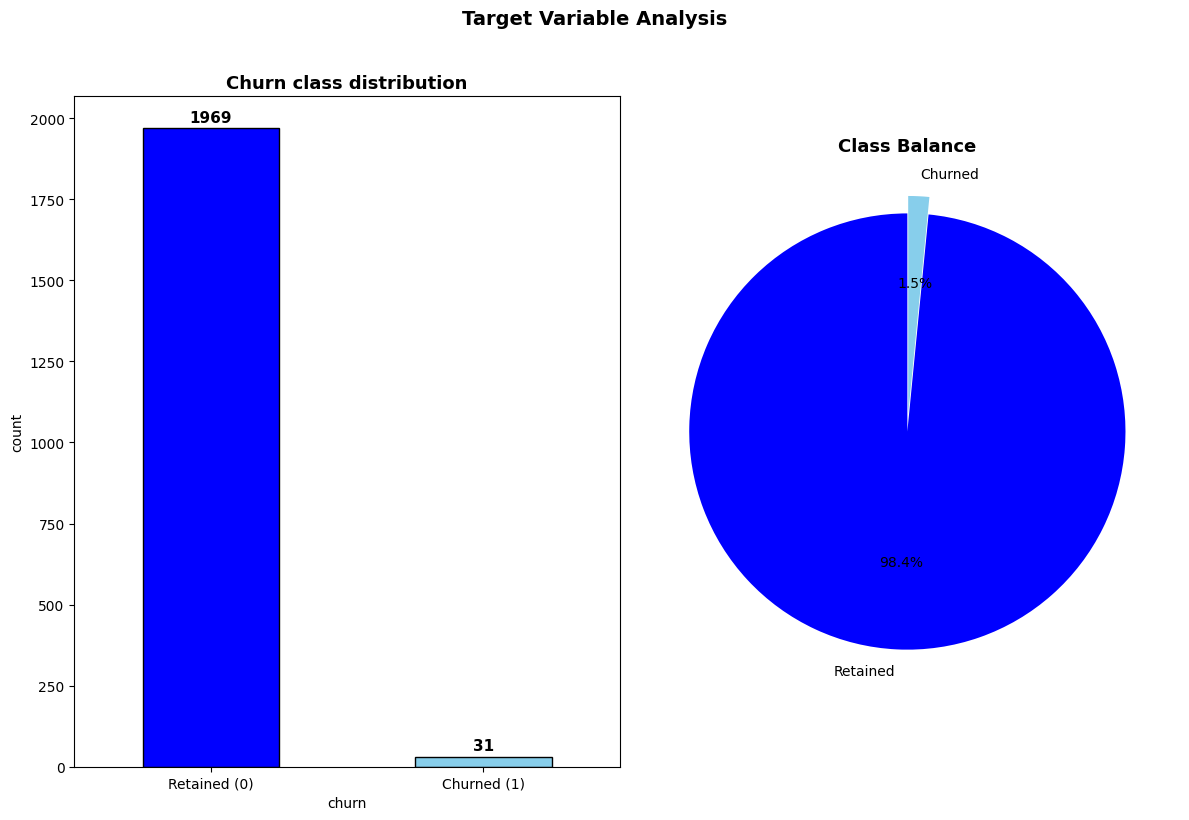

Highly imbalanced: only 1.55% churn. Will apply weights during training.


In [15]:
#Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
counts = df['churn'].value_counts()
counts.plot(kind='bar', ax=axes[0], color=['blue','skyblue'], edgecolor='black')
axes[0].set_title('Churn class distribution', fontweight='bold', fontsize=13)
axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'], rotation=0)
axes[0].set_ylabel('count')
for p in axes[0].patches: #the number on top of each bar
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height() + 20),
                     ha='center', fontsize=11, fontweight='bold')
    
axes[1].pie([1969,31], labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['blue','skyblue'],
            startangle=90, explode=(0, 0.08))
axes[1].set_title('Class Balance', fontweight='bold', fontsize=13)
plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold', y=1.02)
import os
os.makedirs('results', exist_ok=True)
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Highly imbalanced: only 1.55% churn. Will apply weights during training.')

# Task 2: Data Preprocessing

In [16]:
# Drop identifier column
df_proc = df.drop(columns=['customer_id'])

# One-hot encode categorical columns
cat_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
df_enc = pd.get_dummies(df_proc, columns=cat_cols, drop_first=True)

print(f'Features after one-hot encoding: {df_enc.shape[1] - 1}')
print(df_enc.head(3))

Features after one-hot encoding: 24
   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             3                   1          82.17   
2                             0                  11          89.39   

   satisfaction_score  last_complaint_days_ago  discount_percent  \
0                 8.0                       67                 0   
1                 5.7                       69                 0   
2                 6.4                       63                10   

   autopay_enabled  ...  region_West  plan_type_Enterprise  plan_type_Premium  \
0                0  ...        False                 False  

In [17]:
# Features and target

X = df_enc.drop(columns=['churn']).values.astype(np.float32)
y = df_enc['churn'].values.astype(np.float32)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

#Standard scaling 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'X_train: {X_train.shape} |  X_test: {X_test.shape}')
print(f'y_train churn %: {y_train.mean()*100:.2f}% | y_test churn %: {y_test.mean()*100:.2f}%')


X_train: (1600, 24) |  X_test: (400, 24)
y_train churn %: 1.56% | y_test churn %: 1.50%


# Task 3: Neural Network Model Building

In [ ]:
def build_model(hidden_layers = [(64, 'relu'), (32, 'relu')], lr=0.001):
    """
    Build a feed-forward neural network.
    -hidden_layers: list of (units, activation) tuples
    _lr:Learing rate for Adam optimizer
    """
    inp = keras.Input(shape=(X_train.shape[1],)) #expect 24 numbers as input for each row 
    x = inp
    for units, act in hidden_layers:
        x = layers.Dense(units, activation=act)(x)
    out = layers.Dense(1, activation='sigmoid')(x) #binary output
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr), #the algorithm that updates weights during training
        loss='binary_crossentropy', #measures how wrong the predictions are for binary (yes/no) problems
        metrics=['accuracy'] #track accuracy
    )
    return model

# Baseline model
model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Training and Evaluation

In [19]:
#Class weights to handle severe imbalance (1969 vs 31)
class_weight = {0:1.0, 1:30.0}
#penalize mistakes on churners 30x more than mistakes on retained customers.
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9681 - loss: 0.9235 - val_accuracy: 0.9775 - val_loss: 0.3390
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9769 - loss: 0.7500 - val_accuracy: 0.9600 - val_loss: 0.3164
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9613 - loss: 0.6550 - val_accuracy: 0.9525 - val_loss: 0.2852
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9531 - loss: 0.5770 - val_accuracy: 0.9400 - val_loss: 0.2527
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9488 - loss: 0.5111 - val_accuracy: 0.9325 - val_loss: 0.2289
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9488 - loss: 0.4528 - val_accuracy: 0.9325 - val_loss: 0.2068
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9438 - loss: 0.4032 - val_accuracy: 0.9400 - val_loss: 0.1895
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9444 - loss: 0.3588 - val_accuracy: 0.9475 - val_loss:

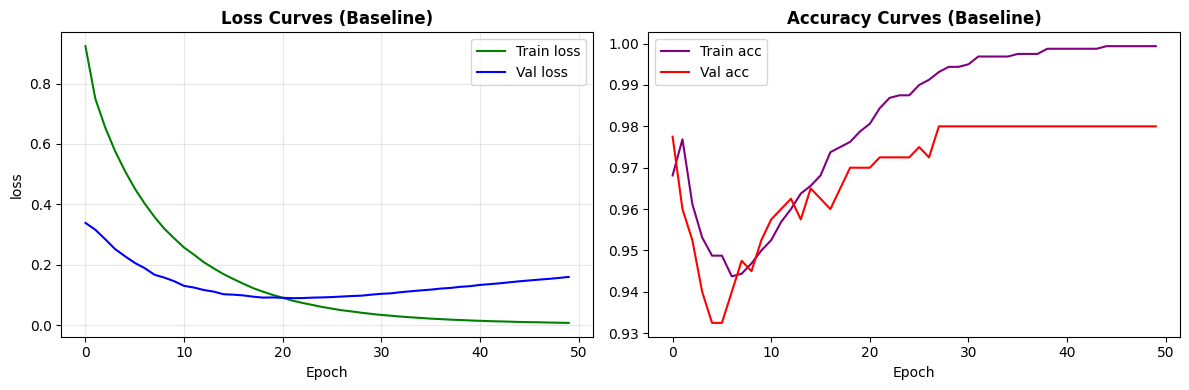

Final Train Acc: 0.9994
Final Val Acc: 0.9800
Final Train Loss: 0.0083
Final Val Loss: 0.1603


In [ ]:
# Plot learning curves

fig, axes = plt.subplots(1, 2, figsize=(12,4))
#If val_loss goes up while train_loss goes down → overfitting
axes[0].plot(history.history['loss'], label='Train loss', color='green') #training loss per epoch
axes[0].plot(history.history['val_loss'], label='Val loss', color='blue') #validation (test) loss per epoch
axes[0].set_title('Loss Curves (Baseline)', fontweight = 'bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train acc', color='purple') 
axes[1].plot(history.history['val_accuracy'], label='Val acc', color='red')
axes[1].set_title('Accuracy Curves (Baseline)', fontweight = 'bold')
axes[1].set_xlabel('Epoch'); axes[0].set_ylabel('loss')
axes[1].legend(); axes[0].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final Train Acc: {history.history["accuracy"][-1]:.4f}')
print(f'Final Val Acc: {history.history["val_accuracy"][-1]:.4f}')
print(f'Final Train Loss: {history.history["loss"][-1]:.4f}')
print(f'Final Val Loss: {history.history["val_loss"][-1]:.4f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Classification Report:
              precision    recall  f1-score   support

    Retained       0.99      0.99      0.99       394
     Churned       0.25      0.17      0.20         6

    accuracy                           0.98       400
   macro avg       0.62      0.58      0.59       400
weighted avg       0.98      0.98      0.98       400



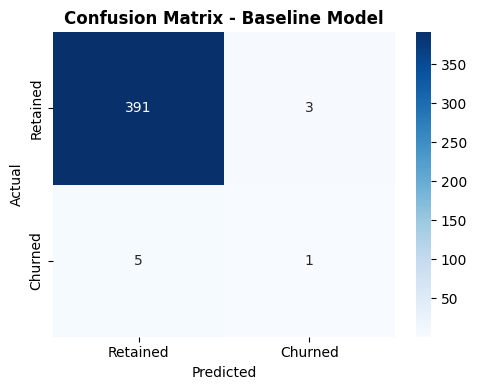

In [25]:
#Predict and evaluate

y_pred_prob = model.predict(X_test).flatten() #converts 2D array to 1D (cleaner to work with)
y_pred = (y_pred_prob > 0.5).astype(int) #if probability is above 50%, classify as churned (1), else retained (0)

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Retained','Churned'],
            yticklabels=['Retained','Churned'])
ax.set_title('Confusion Matrix - Baseline Model', fontweight='bold')
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

**Interpretation**
1) The model shows a very high accuracy (~98%), but that can be a bit misleading because the dataset is heavily imbalanced. Since most customers are “Retained,” the model can achieve high accuracy even by predicting the majority class most of the time.

2) Using class-weighted loss improved the model’s ability to identify churners, which is important because churn cases are much fewer compared to retained customers. This is reflected in the non-zero recall for the minority class.

3) In this case, the F1-score for the churn class is the most important metric to focus on, as it gives a better balance between precision and recall. Accuracy alone does not properly represent how well the model detects actual churners.

# Task 5: Hyperparameter Experimentation

In [29]:
import os
os.makedirs('results', exist_ok=True)

configs = [
    {'name':'Exp1: Baseline (64-32, ReLU, lr=0.001)',
     'hidden':[(64, 'relu'), (32,'relu')], 'lr':0.001, 'epochs': 50, 'batch': 32},
    {'name':'Exp2: Deeper (64-32, ReLU, lr=0.001)',
     'hidden':[(128, 'relu'), (64,'relu'), (32,'relu')], 'lr':0.001, 'epochs': 50, 'batch': 32},
    {'name':'Exp3: High LR (64-32, ReLU, lr=0.001)',
     'hidden':[(64, 'relu'), (32,'relu')], 'lr':0.01, 'epochs': 50, 'batch': 32},
    {'name':'Exp4: Low LR (64-32, ReLU, lr=0.001)',
     'hidden':[(64, 'relu'), (32,'relu')], 'lr':0.0001, 'epochs': 50, 'batch': 32},
    {'name':'Exp5: Tanh (64-32, Tanh, lr=0.001, batch=64)',
     'hidden':[(64, 'tanh'), (32,'tanh')], 'lr':0.001, 'epochs': 50, 'batch': 64},
]

results = []
for cfg in configs:
    m = build_model(cfg['hidden'], cfg['lr'])
    h = m.fit(X_train, y_train,
              validation_data=(X_test, y_test),
              epochs=cfg['epochs'],
              batch_size=cfg['batch'],
              class_weight={0:1.0, 1:30.0},
              verbose=0)
    yp = (m.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    results.append({
        'Experiment' : cfg['name'],
        'Hidden Arch': str([u for u,_ in cfg['hidden']]),
        'Activation' : cfg['hidden'][0][1],
        'LR' : cfg['lr'],
        'Batch' : cfg['batch'],
        'Train Acc' : round(h.history['accuracy'][-1], 4),
        'Val Acc' : round(h.history['val_accuracy'][-1], 4),
        'Train Loss' : round(h.history['loss'][-1], 4),
        'Val Loss' : round(h.history['val_loss'][-1], 4),
        'F1 score' : round(f1_score(y_test, yp, zero_division=0),4),
        'Recall' : round(recall_score(y_test, yp, zero_division=0), 4),
        'Precision' : round(precision_score(y_test, yp, zero_division=0), 4),
    })
    print(f" {cfg['name']} | F1={results[-1]['F1 score']} | Val Acc={results[-1]['Val Acc']}")    

df_results = pd.DataFrame(results)
df_results.to_csv('results/model_comparison_table.csv', index=False)
print('\nSaved comparison table to results/model_comaprison_table.csv')

 Exp1: Baseline (64-32, ReLU, lr=0.001) | F1=0.1818 | Val Acc=0.9775
 Exp2: Deeper (64-32, ReLU, lr=0.001) | F1=0.2 | Val Acc=0.98
 Exp3: High LR (64-32, ReLU, lr=0.001) | F1=0.1818 | Val Acc=0.9775
 Exp4: Low LR (64-32, ReLU, lr=0.001) | F1=0.2581 | Val Acc=0.9425
 Exp5: Tanh (64-32, Tanh, lr=0.001, batch=64) | F1=0.2222 | Val Acc=0.965

Saved comparison table to results/model_comaprison_table.csv


In [30]:
#Display comaprison table

display_cols = ['Experiment', 'Hidden Arch', 'Activation', 'LR', 'Batch', 'Train Acc', 'Val Acc',
                'Train Loss', 'Val Loss', 'F1 score', 'Recall', 'Precision']
df_results[display_cols]

,Experiment,Hidden Arch,Activation,LR,Batch,Train Acc,Val Acc,Train Loss,Val Loss,F1 score,Recall,Precision
0,"Exp1: Baseline (64-32, ReLU, lr=0.001)","[64, 32]",relu,0.0010,32,0.9994,0.9775,0.0082,0.1780,0.1818,0.1667,0.2000
1,"Exp2: Deeper (64-32, ReLU, lr=0.001)","[128, 64, 32]",relu,0.0010,32,0.9994,0.9800,0.0034,0.2025,0.2000,0.1667,0.2500
2,"Exp3: High LR (64-32, ReLU, lr=0.001)","[64, 32]",relu,0.0100,32,0.9994,0.9775,0.0079,0.3215,0.1818,0.1667,0.2000
3,"Exp4: Low LR (64-32, ReLU, lr=0.001)","[64, 32]",relu,0.0001,32,0.9488,0.9425,0.4661,0.2447,0.2581,0.6667,0.1600
4,"Exp5: Tanh (64-32, Tanh, lr=0.001, batch=64)","[64, 32]",tanh,0.0010,64,0.9925,0.9650,0.0573,0.0994,0.2222,0.3333,0.1667


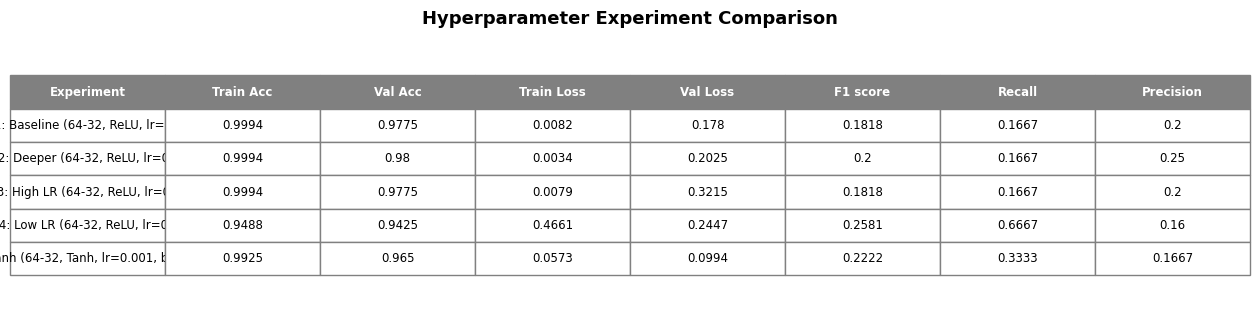

In [32]:
#Save comparison table as an image
import matplotlib
show_df = df_results[['Experiment', 'Train Acc', 'Val Acc', 'Train Loss', 'Val Loss', 'F1 score', 'Recall', 'Precision']]
fig, ax = plt.subplots(figsize=(16, 3.5))
ax.axis('off')
tbl = ax.table(cellText=show_df.values, colLabels=show_df.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 2.0)
for(r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('grey')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 ==0:
        cell.set_facecolor('white')
    else:
        cell.set_facecolor('white')
    cell.set_edgecolor('grey')
plt.title('Hyperparameter Experiment Comparison', fontsize=13, fontweight='bold', pad=12)
plt.savefig('results/model_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()

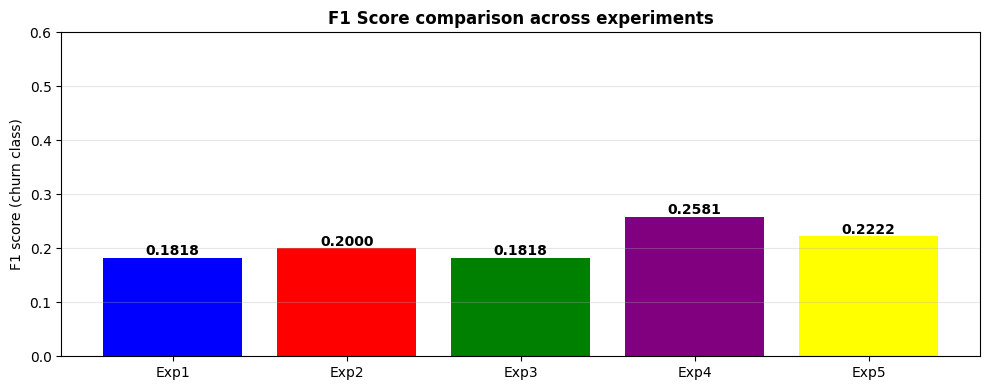

In [33]:
# F1 score bar chart
fig, ax = plt.subplots(figsize=(10, 4))
exp_short = [f'Exp{i+1}' for i in range(len(df_results))]
bars = ax.bar(exp_short, df_results['F1 score'],
              color = ['blue','red','green','purple','yellow'])
ax.set_title('F1 Score comparison across experiments', fontweight='bold')
ax.set_ylabel('F1 score (churn class)'); ax.set_ylim(0, 0.6)
for bar, val in zip(bars, df_results['F1 score']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', dpi=150, bbox_inches='tight')
plt.show()

# Task 6: Final Reflection

**What role do weights and biases play in the model?**

Weights decide how important each input feature is for the prediction. During training, the model keeps adjusting these weights so it can learn which features should have a stronger or weaker impact on the final output.

Biases act like adjustable offsets added to each neuron. They help the model shift the activation function and learn patterns more flexibly, instead of forcing every relationship to pass through zero. Without biases, the model would be much less capable of capturing real-world patterns.

**Why is an activation function required?**

Activation functions are what make neural networks powerful. Without them, even a deep network with many layers would behave like a simple linear model and could only learn straight-line relationships.

Functions like ReLU and Tanh introduce non-linearity, allowing the model to capture more complex patterns and decision boundaries in the data. The Sigmoid activation used in the output layer converts the result into a value between 0 and 1, which can be interpreted as the probability of customer churn.

**What happens when the learning rate is too high or too low?**

Learning rate too high (Exp3, lr = 0.01):
The optimizer updates weights too aggressively and may overshoot the optimal solution. This can make training unstable, causing the loss to fluctuate instead of improving smoothly. In our experiment, the validation loss became higher than the baseline even though training accuracy was almost perfect, showing unstable learning.
Learning rate too low (Exp4, lr = 0.0001):
The model learns very slowly because the updates are extremely small. As a result, it needs many more epochs to converge. In Exp4, the model still had lower training accuracy after 50 epochs compared to the baseline, which suggests it had not fully learned yet within the given training time.

**Did your model show signs of underfitting or overfitting?**

The baseline model showed signs of mild overfitting. Training accuracy became extremely high (99.94%), while validation accuracy was slightly lower (98%). Also, the training loss was much smaller than the validation loss, which usually means the model learned the training data too well but struggled to generalize perfectly to unseen data.

This issue is likely influenced by the imbalanced dataset, where churn cases were very limited compared to retained customers.

Among all experiments, the Tanh model (Exp5) performed slightly better in terms of F1-score and had a smaller gap between training and validation performance, suggesting better generalization. Techniques like dropout or L2 regularization could further reduce overfitting in future improvements.